### Imports + cleaned dataset load

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "telco_churn_clean.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Quick validation

In [3]:
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.info()

Shape: (7043, 21)
Missing values: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16 

### Churn convert numerical flag

In [4]:
df["ChurnFlag"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [5]:
df[["Churn", "ChurnFlag"]].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


### Overall churn rate

In [6]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
churn_rate = df["ChurnFlag"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


### Target distribution plot

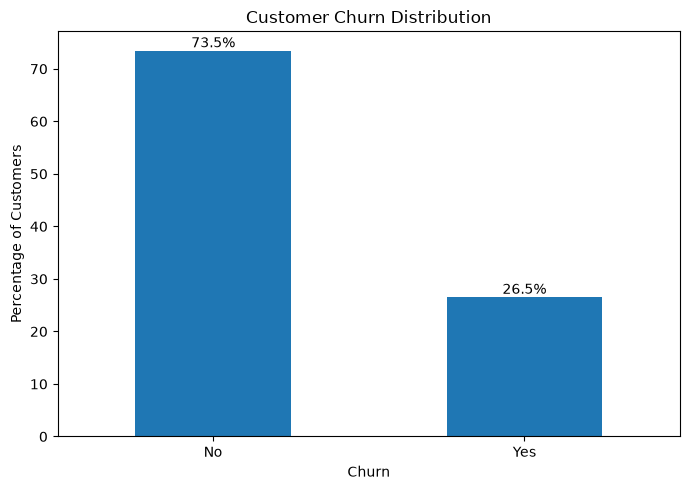

In [8]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

ax = churn_percentage.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Reusable Churn Summary Function

Instead of repeating the same aggregation boilerplate code for every single categorical variable—
which makes the notebook look like a tedious government form—we use a reusable summary function. 
This keeps our EDA clean, modular, and easy to maintain.


In [10]:
def churn_summary(data, column):
    summary = (
        data.groupby(column)["ChurnFlag"]
        .agg(
            customers="count",
            churned="sum",
            churn_rate="mean"
        )
        .reset_index()
    )

    summary["churn_rate"] = (
        summary["churn_rate"] * 100
    ).round(2)

    return summary.sort_values(
        "churn_rate",
        ascending=False
    )

In [11]:
# test
churn_summary(df, "Contract")

,Contract,customers,churned,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


### Contract vs Churn

In [12]:
contract_summary = churn_summary(
    df,
    "Contract"
)

contract_summary

,Contract,customers,churned,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


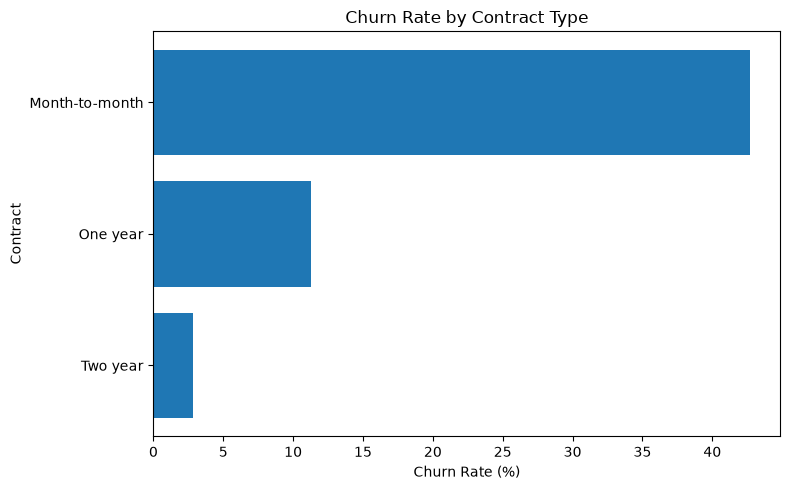

In [13]:
# plot
plot_data = contract_summary.sort_values(
    "churn_rate",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Contract"],
    plot_data["churn_rate"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Contract")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "churn_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Contract
Month-to-month customers had the highest observed churn rate
(42.71%), compared with one-year (11.27%) and two-year
contracts (2.83%). This suggests a strong association between
short-term contracts and churn in this dataset.

#### Internet Service vs Churn

In [14]:
internet_summary = churn_summary(
    df,
    "InternetService"
)

internet_summary

,InternetService,customers,churned,churn_rate
1,Fiber optic,3096,1297,41.89
0,DSL,2421,459,18.96
2,No,1526,113,7.40


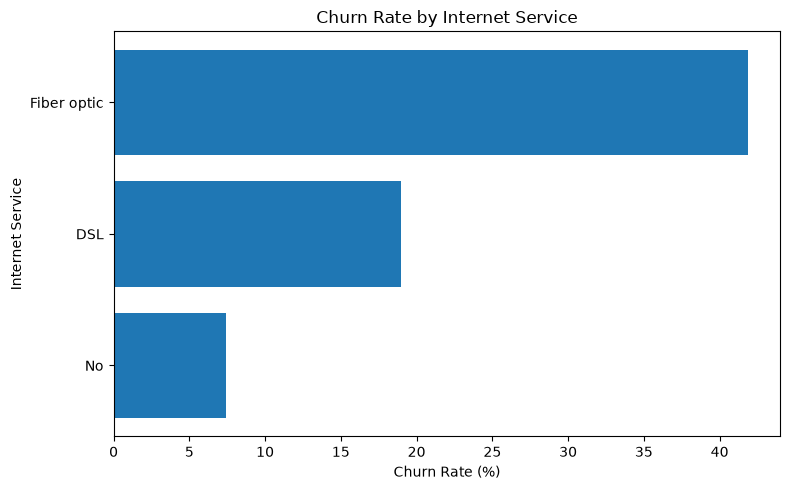

In [15]:
#plot
plot_data = internet_summary.sort_values(
    "churn_rate",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["InternetService"],
    plot_data["churn_rate"]
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Internet Service")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "churn_by_internet_service.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Payment Method

In [16]:
payment_summary = churn_summary(
    df,
    "PaymentMethod"
)

payment_summary

,PaymentMethod,customers,churned,churn_rate
2,Electronic check,2365,1071,45.29
3,Mailed check,1612,308,19.11
0,Bank transfer (automatic),1544,258,16.71
1,Credit card (automatic),1522,232,15.24


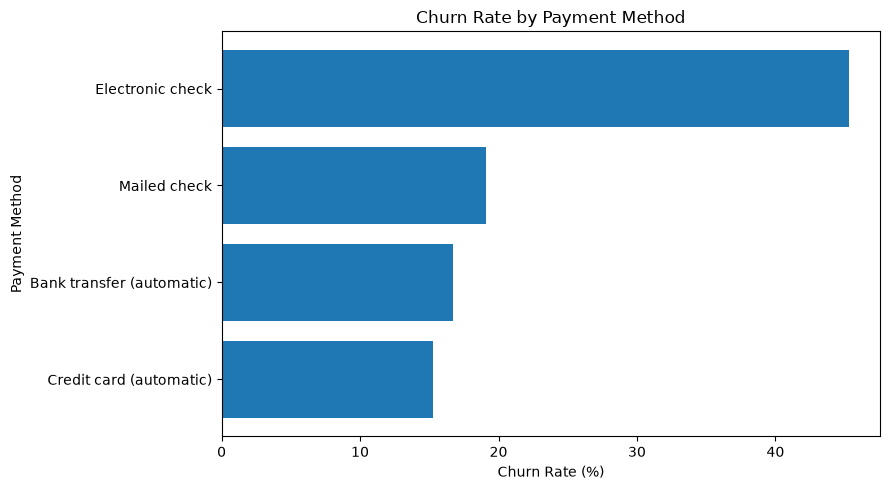

In [17]:
#plot 
plot_data = payment_summary.sort_values(
    "churn_rate",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["PaymentMethod"],
    plot_data["churn_rate"]
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "churn_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Tech Support

In [18]:
tech_support_summary = churn_summary(
    df,
    "TechSupport"
)

tech_support_summary

,TechSupport,customers,churned,churn_rate
0,No,3473,1446,41.64
2,Yes,2044,310,15.17
1,No internet service,1526,113,7.40


#### Online Security

In [19]:
online_security_summary = churn_summary(
    df,
    "OnlineSecurity"
)

online_security_summary

,OnlineSecurity,customers,churned,churn_rate
0,No,3498,1461,41.77
2,Yes,2019,295,14.61
1,No internet service,1526,113,7.40


#### Paperless Billing

In [20]:
churn_summary(
    df,
    "PaperlessBilling"
)

,PaperlessBilling,customers,churned,churn_rate
1,Yes,4171,1400,33.57
0,No,2872,469,16.33


#### Senior Citizen

In [21]:
churn_summary(
    df,
    "SeniorCitizen"
)

,SeniorCitizen,customers,churned,churn_rate
1,1,1142,476,41.68
0,0,5901,1393,23.61


#### Gender sanity check

In [22]:
churn_summary(
    df,
    "gender"
)

,gender,customers,churned,churn_rate
0,Female,3488,939,26.92
1,Male,3555,930,26.16


#### Tenure vs Churn

In [23]:
df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Churn,,,,,
No,5174,37.569965,38.0,0,72
Yes,1869,17.979133,10.0,1,72


#### Tenure histogram

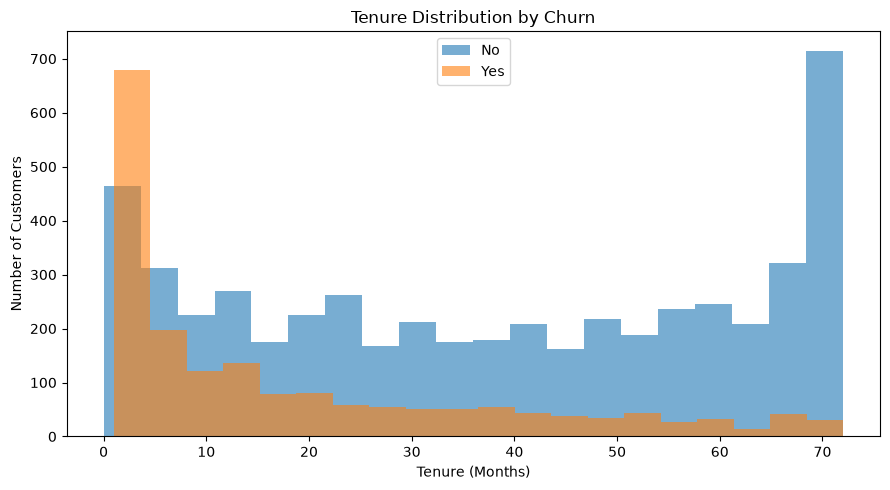

In [24]:
plt.figure(figsize=(9, 5))

plt.hist(
    df.loc[df["Churn"] == "No", "tenure"],
    bins=20,
    alpha=0.6,
    label="No"
)

plt.hist(
    df.loc[df["Churn"] == "Yes", "tenure"],
    bins=20,
    alpha=0.6,
    label="Yes"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "tenure_distribution_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### create Tenure groups

In [25]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [26]:
tenure_summary = churn_summary(
    df,
    "tenure_group"
)

tenure_summary

,tenure_group,customers,churned,churn_rate
0,0-6 months,1481,784,52.94
1,7-12 months,705,253,35.89
2,13-24 months,1024,294,28.71
3,25-48 months,1594,325,20.39
4,49-72 months,2239,213,9.51


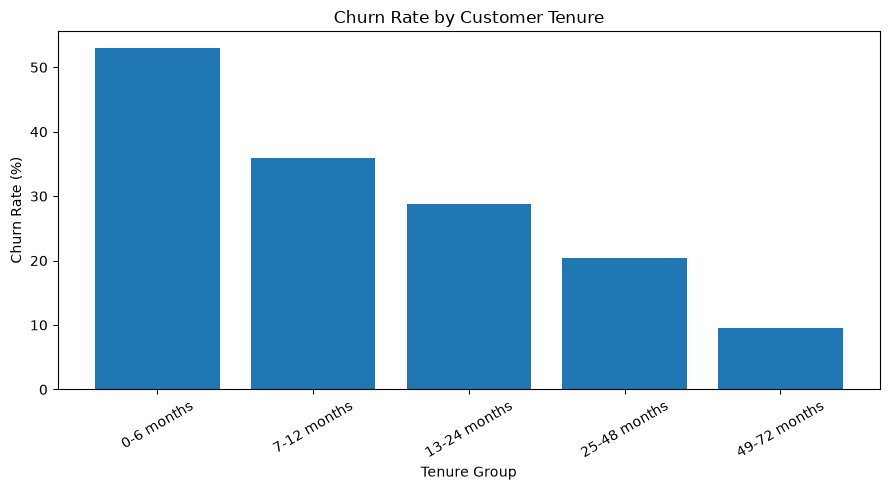

In [27]:
# plot
tenure_plot = tenure_summary.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    tenure_plot["tenure_group"].astype(str),
    tenure_plot["churn_rate"]
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "churn_by_tenure_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Monthly Charges vs Churn

In [28]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
Churn,,,
No,61.265124,64.425,31.092648
Yes,74.441332,79.650,24.666053


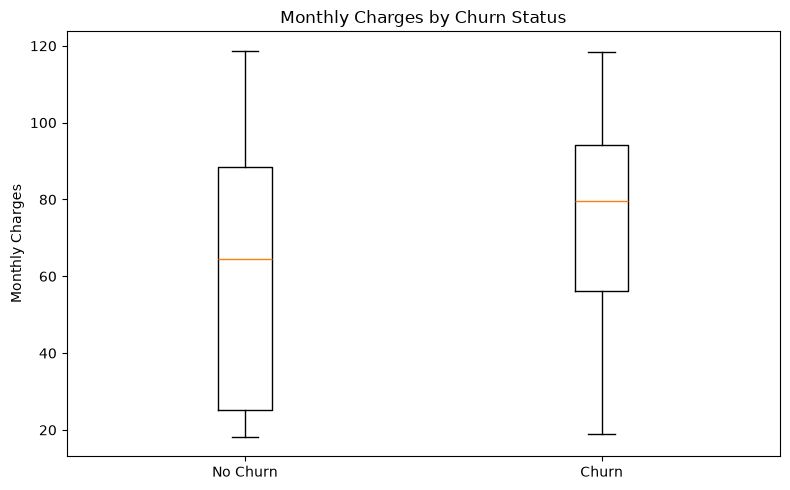

In [31]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df.loc[df["Churn"] == "No", "MonthlyCharges"],
        df.loc[df["Churn"] == "Yes", "MonthlyCharges"]
    ],
    tick_labels=["No Churn", "Churn"]
)

plt.title("Monthly Charges by Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "monthly_charges_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Total Charges

In [32]:
df.groupby("Churn")["TotalCharges"].agg(
    ["mean", "median"]
)

,mean,median
Churn,,
No,2549.911442,1679.525
Yes,1531.796094,703.550


#### Inspect a few more categorical variables together.

In [33]:
columns_to_check = [
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineBackup",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies"
]

for column in columns_to_check:
    print(f"\n--- {column} ---")
    print(churn_summary(df, column))


--- Partner ---
  Partner  customers  churned  churn_rate
0      No       3641     1200       32.96
1     Yes       3402      669       19.66

--- Dependents ---
  Dependents  customers  churned  churn_rate
0         No       4933     1543       31.28
1        Yes       2110      326       15.45

--- PhoneService ---
  PhoneService  customers  churned  churn_rate
1          Yes       6361     1699       26.71
0           No        682      170       24.93

--- MultipleLines ---
      MultipleLines  customers  churned  churn_rate
2               Yes       2971      850       28.61
0                No       3390      849       25.04
1  No phone service        682      170       24.93

--- OnlineBackup ---
          OnlineBackup  customers  churned  churn_rate
0                   No       3088     1233       39.93
2                  Yes       2429      523       21.53
1  No internet service       1526      113        7.40

--- DeviceProtection ---
      DeviceProtection  customers  churn

In [34]:
# Important Data Science Decision
df["tenure_group"]

0         0-6 months
1       25-48 months
2         0-6 months
3       25-48 months
4         0-6 months
            ...     
7038    13-24 months
7039    49-72 months
7040     7-12 months
7041      0-6 months
7042    49-72 months
Name: tenure_group, Length: 7043, dtype: category
Categories (5, str): ['0-6 months' < '7-12 months' < '13-24 months' < '25-48 months' < '49-72 months']